In [ ]:
!pip install -qq ultralytics
from ultralytics import YOLO
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!git config --global user.name "usuario"  #Aqui se modifica para añadir tu usuario de github
!git config --global user.email "correo"  #Aqui se modifica para añadir tu correo asociado a github

In [ ]:
!git clone https://token@github.com/apeas1/PIDDeteccionVehiculos.git

Cloning into 'PIDDeteccionVehiculos'...
remote: Enumerating objects: 5224, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 5224 (delta 32), reused 11 (delta 4), pack-reused 5141 (from 2)
Receiving objects: 100% (5224/5224), 529.94 MiB | 26.92 MiB/s, done.
Resolving deltas: 100% (55/55), done.
Updating files: 100% (7462/7462), done.


In [ ]:
cd PIDDeteccionVehiculos

/content/PIDDeteccionVehiculos


In [ ]:
#MÉTRICAS TEST
model = YOLO("Entrega_Final/Modelo_Final/best.pt")
model.iou = 0.35
model.conf = 0.45
metrics = model.val(data="dataset.yaml", split="test")    #Se le indica hacer un split para solo coger las imágenes del test

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1559.8±432.6 MB/s, size: 88.4 KB)
val: Scanning /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels... 252 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 290.8it/s 0.9s
val: New cache created: /content/PIDDeteccionVehiculos/VEHICLE-DETECTION-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 23.0s/it 6:08
                   all        252      27305      0.771       0.84      0.841      0.481
                    3W        251       2972      0.823      0.882      0.865      0.393
                   Bus        125        364      0.842       0.92      0.928      0.651
                 Coche        251       8362      0.885      0.956      0.946      0.547
             C

Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation
Precisión: 0.7705571435649199
Recall: 0.8401948137827514
F1 score: 0.8015006377950267
Matriz de confusión:


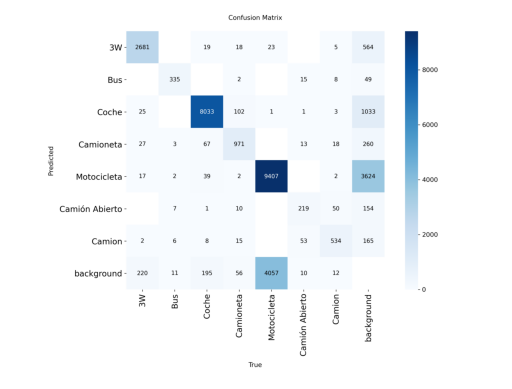

In [ ]:
img = mpimg.imread('runs/detect/val/confusion_matrix.png')   #Modificar la ruta dependiendo donde el código anterior haya guardado las métricas
print("Para el modelo entrenado con 20 epochs, tamaño de batch de 10 y data augmentation")
print("Precisión:",np.average(metrics.box.p))
print("Recall:",np.average(metrics.box.r))
print("F1 score:",np.average(metrics.box.f1))
print("Matriz de confusión:")
plt.imshow(img)
plt.axis('off')
plt.show()